In [1]:
import os
import pickle
import h5py

import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm

from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as patheffects
from sklearn.decomposition import PCA

%matplotlib widget


In [2]:
import string
letters = list(string.ascii_lowercase) + [a + b for a in string.ascii_lowercase for b in string.ascii_lowercase]

In [3]:
def add_cbar(fig1, ax1, im1, ticks=None):
    divider = make_axes_locatable(ax1)
    cax1 = divider.append_axes('right', size='5%', pad=0.05)
    clb = fig1.colorbar(im1, cax=cax1, orientation='vertical')

    if ticks is not None:
        clb.set_ticks(ticks)
        def format_scientific(x):
            if x == 0: return '0'
            sign = '-' if x < 0 else ''
            # Get exponent
            import math
            exponent = int(math.floor(math.log10(abs(x))))
            return f'{sign}$10^{{{exponent}}}$'
            
        labels = [format_scientific(t) for t in ticks]
        clb.set_ticklabels(labels)

In [4]:
# Display the tree structure of the HDF5 file
def print_h5_tree(name, obj):
    """Recursively print the structure of an HDF5 file"""
    indent = '  ' * name.count('/')
    if isinstance(obj, h5py.Group):
        print(f"{indent}{name}/ (Group)")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}{name} (Dataset: shape={obj.shape}, dtype={obj.dtype})")

with h5py.File('data/polycrystal_2D_WS2.h5', 'r') as f:
    
    f.visititems(print_h5_tree)

4DSTEM/ (Group)
  4DSTEM/datacube/ (Group)
    4DSTEM/datacube/calibration/ (Group)
      4DSTEM/datacube/calibration/Q_pixel_size (Dataset: shape=(), dtype=int64)
      4DSTEM/datacube/calibration/Q_pixel_units (Dataset: shape=(), dtype=|S6)
      4DSTEM/datacube/calibration/R_pixel_size (Dataset: shape=(), dtype=int64)
      4DSTEM/datacube/calibration/R_pixel_units (Dataset: shape=(), dtype=|S6)
    4DSTEM/datacube/data (Dataset: shape=(128, 128, 128, 128), dtype=float32)
    4DSTEM/datacube/dim0 (Dataset: shape=(2,), dtype=int64)
    4DSTEM/datacube/dim1 (Dataset: shape=(2,), dtype=int64)
    4DSTEM/datacube/dim2 (Dataset: shape=(2,), dtype=int64)
    4DSTEM/datacube/dim3 (Dataset: shape=(2,), dtype=int64)


In [5]:
# Open the datacube as a 4D numpy array
with h5py.File('data/polycrystal_2D_WS2.h5', 'r') as f:
    # Load the datacube into memory
    datacube = np.array(f['4DSTEM/datacube/data'])
    
print(f"Datacube shape: {datacube.shape}")
print(f"Datacube dtype: {datacube.dtype}")
print(f"Memory size: {datacube.nbytes / 1e9:.2f} GB")

Datacube shape: (128, 128, 128, 128)
Datacube dtype: float32
Memory size: 1.07 GB


In [6]:
X = datacube[2:-2, 2:-2, :, :] # remove artefacts at the edge of real space
Xf = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])

del datacube


In [7]:
x_real, y_real, x_reci, y_reci = X.shape

In [8]:
# PCA - new
n_components = 100
pca = PCA(n_components = n_components)
W = pca.fit_transform(Xf)
H = pca.components_


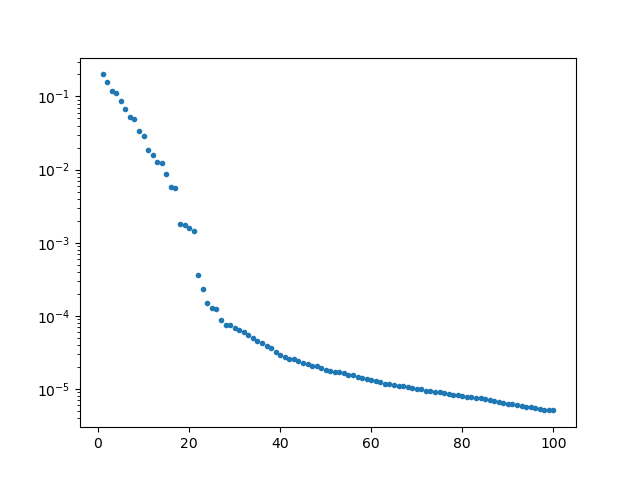

In [9]:

plt.figure()
plt.plot(np.arange(n_components) + 1, pca.explained_variance_ratio_, '.')
plt.yscale('log')

# Key cutoffs: 17, 21, 26 (*PCA* components )

## UMAP and clustering
since this is a crystalline sample with very distinct phases, (little mixing) we can use UMAP to visualize the points

In [10]:

# this cell takes about 40s
from umap import UMAP

transformer = UMAP()
projection = transformer.fit_transform(Xf)

In [11]:
# because this is crystalline we could use HDBSCAN - on the projection 
# This will allow us to verify clusters.

from sklearn.cluster import HDBSCAN

cluster = HDBSCAN(min_cluster_size=200).fit(projection)

In [12]:
print(projection.shape)
print(np.sort(np.unique(cluster.labels_)))

(15376, 2)
[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


Interestingly, we get only 20 clusters (points labeled -1 are outliers).

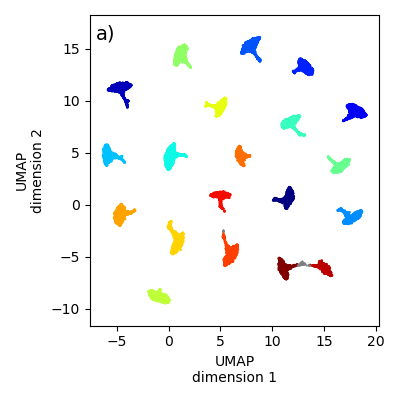

In [13]:
plt.figure(figsize=(4,4))
plt.plot(projection[cluster.labels_==-1, 0], projection[cluster.labels_==-1, 1], '.', ms=1, color='tab:grey')
plt.scatter(projection[cluster.labels_ !=-1, 0], projection[cluster.labels_ !=-1, 1], c=cluster.labels_[cluster.labels_ !=-1], s=1, cmap='jet')

plt.axis('equal')
plt.xlabel('UMAP\ndimension 1')
plt.ylabel('UMAP\ndimension 2')
plt.tight_layout()
plt.gca().text(
    0.02, 0.97, 'a)', transform=plt.gca().transAxes, fontsize=14, va='top', ha='left',
    color='k', 
)
plt.savefig('figures/WS2_umap.png', dpi=300)



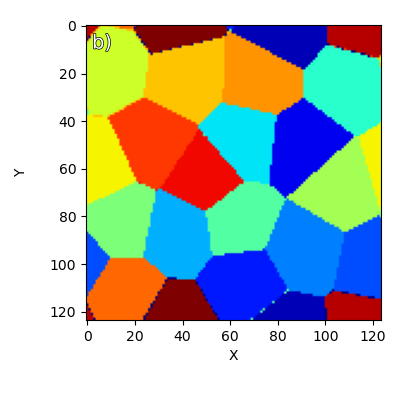

In [14]:
plt.figure(figsize=(4,4))
plt.imshow(cluster.labels_.reshape(X.shape[0], X.shape[1]), cmap='jet');
# plt.imshow(cluster.labels_[unshuffle_ix].reshape(X.shape[0], X.shape[1]), cmap='jet');
plt.gca().text(
    0.02, 0.97, 'b)', transform=plt.gca().transAxes, fontsize=14, va='top', ha='left',
    color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')]
)
plt.xlabel('X\n')
plt.ylabel('Y\n')
plt.tight_layout()
plt.savefig('figures/WS2_clusters.png', dpi=300)

So this is the conundrum:
- PCA analysis is not super clear. We seem to have 21 *PCA* components. We are not 100% sure whether the mean should be an additional degree of freedom...
- Cluster analysis on a UMAP projection (which would make sense in the case of unique regions) shows 20 unique clusters.
How many components to use for NMF?

## PCA figure

In [15]:
# PCA - new
from sklearn.decomposition import PCA
k = 20
pca = PCA(n_components = k)
W = pca.fit_transform(Xf)
H = pca.components_
# H[0, :] += pca.mean_
print(H.shape, W.shape)

(20, 16384) (15376, 20)


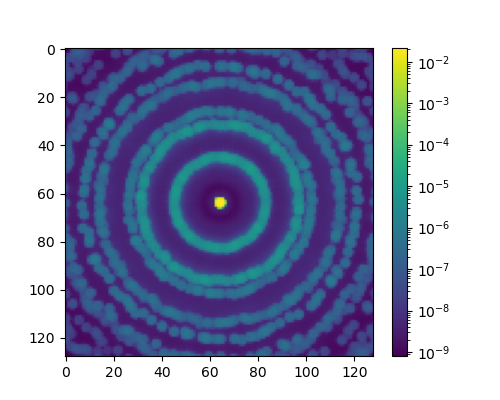

In [16]:
plt.figure(figsize=(5,4))
plt.imshow(pca.mean_.reshape((x_reci, y_reci)), norm=LogNorm())
plt.colorbar()

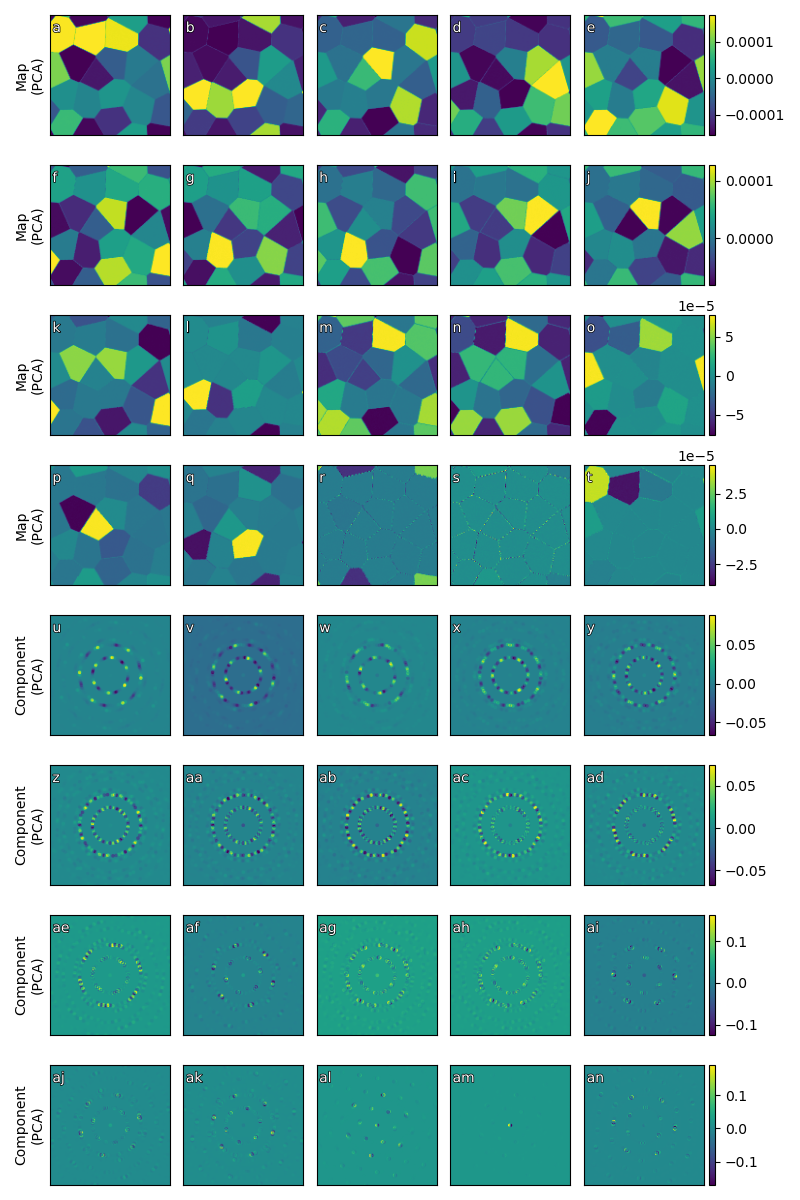

In [17]:
fig, axs = plt.subplots(nrows=8, ncols=5, figsize=(8, 12), width_ratios=[1,1,1,1,1.1])

# Plot spatial maps (Wr) in top 4 rows (5x4 grid = 20 components)
for i in range(k):
    row = i // 5  # 0-3
    col = i % 5   # 0-4
    im = axs[row, col].imshow(W[:, i].reshape((x_real, y_real)), cmap='viridis')
    # axs[row, col].set_title(f'', fontsize=8)
    # axs[row, col].axis('off')
    axs[row, col].set_xticks([])
    axs[row, col].set_yticks([])
    if col == 0:
        axs[row, col].set_ylabel("Map\n(PCA)")

    if col == 4:
        add_cbar(fig, axs[row, col], im)


# Plot reciprocal maps (Hr) in bottom 4 rows (5x4 grid = 20 components)
for i in range(k):
    row = (i // 5) + 4  # 4-7
    col = i % 5         # 0-4
    im = axs[row, col].imshow(H[i, :].reshape((x_reci, y_reci)), cmap='viridis') # , norm=SymLogNorm(linthresh=1e-8)
    # axs[row, col].set_title(f'H{i}', fontsize=8)
    # axs[row, col].axis('off')
    axs[row, col].set_xticks([])
    axs[row, col].set_yticks([])
    if col == 0:
        axs[row, col].set_ylabel("Component\n(PCA)")
    
    if col == 4:
        add_cbar(fig, axs[row, col], im)

for i, ax in enumerate(axs.flat):
    
    ax.text(
        0.02, 0.95, letters[i], transform=ax.transAxes, fontsize=10, va='top', ha='left',
        color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')]
    )
    
plt.tight_layout()
plt.savefig('figures/WS2_20_PCA.png', dpi=300)

## NMF - different factorizations

In [18]:
import time
from math import log, sqrt
from functools import partial

from sklearn.utils import check_random_state
from sklearn.decomposition._nmf import _initialize_nmf, _beta_divergence
from sklearn.decomposition._cdnmf_fast import _update_cdnmf_fast

from scipy import fftpack, linalg, sparse
from sklearn.utils import check_random_state, check_array
from sklearn.utils.extmath import safe_sparse_dot

def random_axis_sample(A, l, axis, random_state):
    return random_state.choice(A.shape[axis], size=l, replace=False)

def random_gaussian_map(A, l, axis, random_state):
    return random_state.standard_normal(size=(A.shape[axis], l)).astype(A.dtype)

def random_uniform_map(A, l, axis, random_state):
    return random_state.uniform(-1, 1, size=(A.shape[axis], l)).astype(A.dtype)

def sparse_random_map(A, l, axis, density, random_state):
    values = (-sqrt(1. / density), sqrt(1. / density))
    data_rvs = partial(random_state.choice, values)
    return sparse.random(A.shape[axis], l, density=density, data_rvs=data_rvs,
                         random_state=random_state, dtype=A.dtype)

def johnson_lindenstrauss(A, l, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    Omega = random_gaussian_map(A, l, axis, random_state)
    if axis == 0:
        return Omega.T.dot(A)
    return A.dot(Omega)

def sparse_johnson_lindenstrauss(A, l, density=None, axis=1, random_state=None):
    random_state = check_random_state(random_state)
    A = np.asarray(A)
    if density is None:
        density = log(A.shape[0]) / A.shape[0]
    Omega = sparse_random_map(A, l, axis, density, random_state)
    if axis == 0:
        return safe_sparse_dot(Omega.T, A)
    return safe_sparse_dot(A, Omega)

def orthonormalize(A, overwrite_a=True, check_finite=False):
    Q, _ = linalg.qr(A, overwrite_a=overwrite_a, check_finite=check_finite,
                     mode='economic', pivoting=False)
    return Q

def perform_subspace_iterations(A, Q, n_iter=2, axis=1):
    if axis == 0:
        Q = Q.T
    Q = orthonormalize(Q)
    for _ in range(n_iter):
        if axis == 0:
            Z = orthonormalize(A.dot(Q))
            Q = orthonormalize(A.T.dot(Z))
        else:
            Z = orthonormalize(A.T.dot(Q))
            Q = orthonormalize(A.dot(Z))
    if axis == 0:
        return Q.T
    return Q

def conjugate_transpose(A):
    if A.dtype == np.complexfloating:
        return A.conj().T
    return A.T

def _compute_rqb(A, rank, oversample, n_subspace, sparse, random_state):
    if sparse:
        Q = sparse_johnson_lindenstrauss(A, rank + oversample,
                                         random_state=random_state)
    else:
        Q = johnson_lindenstrauss(A, rank + oversample, random_state=random_state)
    if n_subspace > 0:
        Q = perform_subspace_iterations(A, Q, n_iter=n_subspace, axis=1)
    else:
        Q = orthonormalize(Q)
    B = conjugate_transpose(Q).dot(A)
    return Q, B

def compute_rqb(A, rank, oversample=20, n_subspace=2, n_blocks=1, sparse=False,
                random_state=None):
    if n_blocks > 1:
        m, n = A.shape
        row_sets = np.array_split(range(m), n_blocks)
        Q_block = []
        K = []
        for rows in row_sets:
            Qtemp, Ktemp = _compute_rqb(np.asarray_chkfinite(A[rows, :]), 
                rank=rank, oversample=oversample, n_subspace=n_subspace, 
                sparse=sparse, random_state=random_state)
            Q_block.append(Qtemp)
            K.append(Ktemp)
        Q_small, B = _compute_rqb(
            np.concatenate(K, axis=0), rank=rank, oversample=oversample,
            n_subspace=n_subspace, sparse=sparse, random_state=random_state)
        Q_small = np.vsplit(Q_small, n_blocks)
        Q = [Q_block[i].dot(Q_small[i]) for i in range(n_blocks)]
        Q = np.concatenate(Q, axis=0)
    else:
        Q, B = _compute_rqb(np.asarray_chkfinite(A), 
            rank=rank, oversample=oversample, n_subspace=n_subspace,
            sparse=sparse, random_state=random_state)
    return Q, B

def nmf(X, rank, init='nndsvd', maxiter=200, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 random_state=None):
    random_state = check_random_state(random_state)
    X = np.asarray_chkfinite(X)
    X = check_array(X, accept_sparse="csr")
    m, n = X.shape
    flipped = False
    if n > m:
        X = X.T
        m, n = X.shape
        flipped = True
    if np.any(X < 0):
        raise ValueError("Input matrix with nonnegative elements is required.")
        
    W, H = _initialize_nmf(X, rank, init=init, eps=1e-6, random_state=random_state)
    Ht = np.array(H.T, order='C')

    if QB_project:
        Q, B = compute_rqb(X, rank, oversample=oversample,
                        n_subspace=n_subspace, random_state=random_state)
        W_tilde = Q.T.dot(W)
    
    if calculate_loss:
        losses = []
        tols = []

    violation = 0.0
    for niter in range(maxiter):
        if QB_project:
            WtW = W.T.dot(W)
            BtW = B.T.dot(W_tilde)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, BtW, permutation.astype(np.intp))
            
            HHt = Ht.T.dot(Ht)
            BHt = Q.dot(B.dot(Ht))
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, BHt, permutation.astype(np.intp))

            W_tilde = Q.T.dot(W)
        else:
            WtW = W.T.dot(W)
            XtW = X.T.dot(W)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation = _update_cdnmf_fast(Ht, WtW, XtW, permutation.astype(np.intp))

            HHt = np.dot(Ht.T, Ht)
            XHt = safe_sparse_dot(X, Ht)
            permutation = random_state.permutation(rank) if shuffle else np.arange(rank)
            violation += _update_cdnmf_fast(W, HHt, XHt, permutation.astype(np.intp))

        if niter == 0:
            if violation == 0: break
            violation_init = violation

        if calculate_loss:
            if flipped:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            else:
                loss = _beta_divergence(X, W, Ht.T, 2, square_root=True)
            losses.append(loss)
            tols.append(violation / violation_init)

    if calculate_loss:
        if flipped:
            return(Ht, W.T, np.array(losses), np.array(tols))
        return(W, Ht.T, np.array(losses), np.array(tols))
    if flipped:
        return(Ht, W.T)
    return(W, Ht.T)


In [19]:
import os
import time
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

def run_nmf_and_plot(k, ncols=6):
    print(f"--- Running NMF and visualization for k = {k} ---")
    if os.path.exists(f'factorizations/WS2_{k}.pkl'):
        with open(f'factorizations/WS2_{k}.pkl', 'rb') as f:
            W, H = pickle.load(f)
    else:
        start = time.time()
        W, H = nmf(Xf, k, init='nndsvd', maxiter=1000, calculate_loss=False, 
                 QB_project=True, oversample=20, n_subspace=2, shuffle=False,
                 random_state=None)
        stop = time.time()
        
        scale = H.max(axis=1)
        H /= scale[:, np.newaxis]
        W *= scale
        
        print(f"Time taken to compute: {stop - start:.2f} s")
        os.makedirs('factorizations', exist_ok=True)
        with open(f'factorizations/WS2_{k}.pkl', 'wb') as f:
            pickle.dump((W, H), f)

    # Compute appropriate rows
    nrows_per = int(np.ceil(k / ncols))
    # Keep figure width max 12 (using 10 here), calculate height based on number of rows
    fig, axs = plt.subplots(nrows=nrows_per*2, ncols=ncols, figsize=(12, nrows_per*4))

    letter_idx = 0

    for i in range(k):
        row_w = i // ncols
        col = i % ncols
        im = axs[row_w, col].imshow(W[:, i].reshape(X.shape[0], X.shape[1]), cmap='viridis')
        if col == ncols - 1 or i == k - 1:
            add_cbar(fig, axs[row_w, col], im)
        axs[row_w, col].set_xticks([])
        axs[row_w, col].set_yticks([])
        if col == 0:
            axs[row_w, col].set_ylabel('W')
            
        axs[row_w, col].text(
            0.02, 0.95, letters[letter_idx], transform=axs[row_w, col].transAxes, fontsize=10, va='top', ha='left',
            color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')]
        )
        letter_idx += 1

    for i in range(k):
        row_h = (i // ncols) + nrows_per
        col = i % ncols
        im = axs[row_h, col].imshow(H[i, :].reshape(X.shape[2], X.shape[3]), cmap='viridis', norm=SymLogNorm(linthresh=1e-2))
        if col == ncols - 1 or i == k - 1:
            add_cbar(fig, axs[row_h, col], im)
        axs[row_h, col].set_xticks([])
        axs[row_h, col].set_yticks([])
        if col == 0:
            axs[row_h, col].set_ylabel('H')
            
        axs[row_h, col].text(
            0.02, 0.95, letters[letter_idx], transform=axs[row_h, col].transAxes, fontsize=10, va='top', ha='left',
            color='w', path_effects=[patheffects.withStroke(linewidth=1, foreground='k')]
        )
        letter_idx += 1

    # Hide unused axes
    for i in range(k, nrows_per * ncols):
        for r_offset in [0, nrows_per]:
            axs[(i // ncols) + r_offset, i % ncols].axis('off')

    plt.tight_layout()
    plt.show()

--- Running NMF and visualization for k = 20 ---


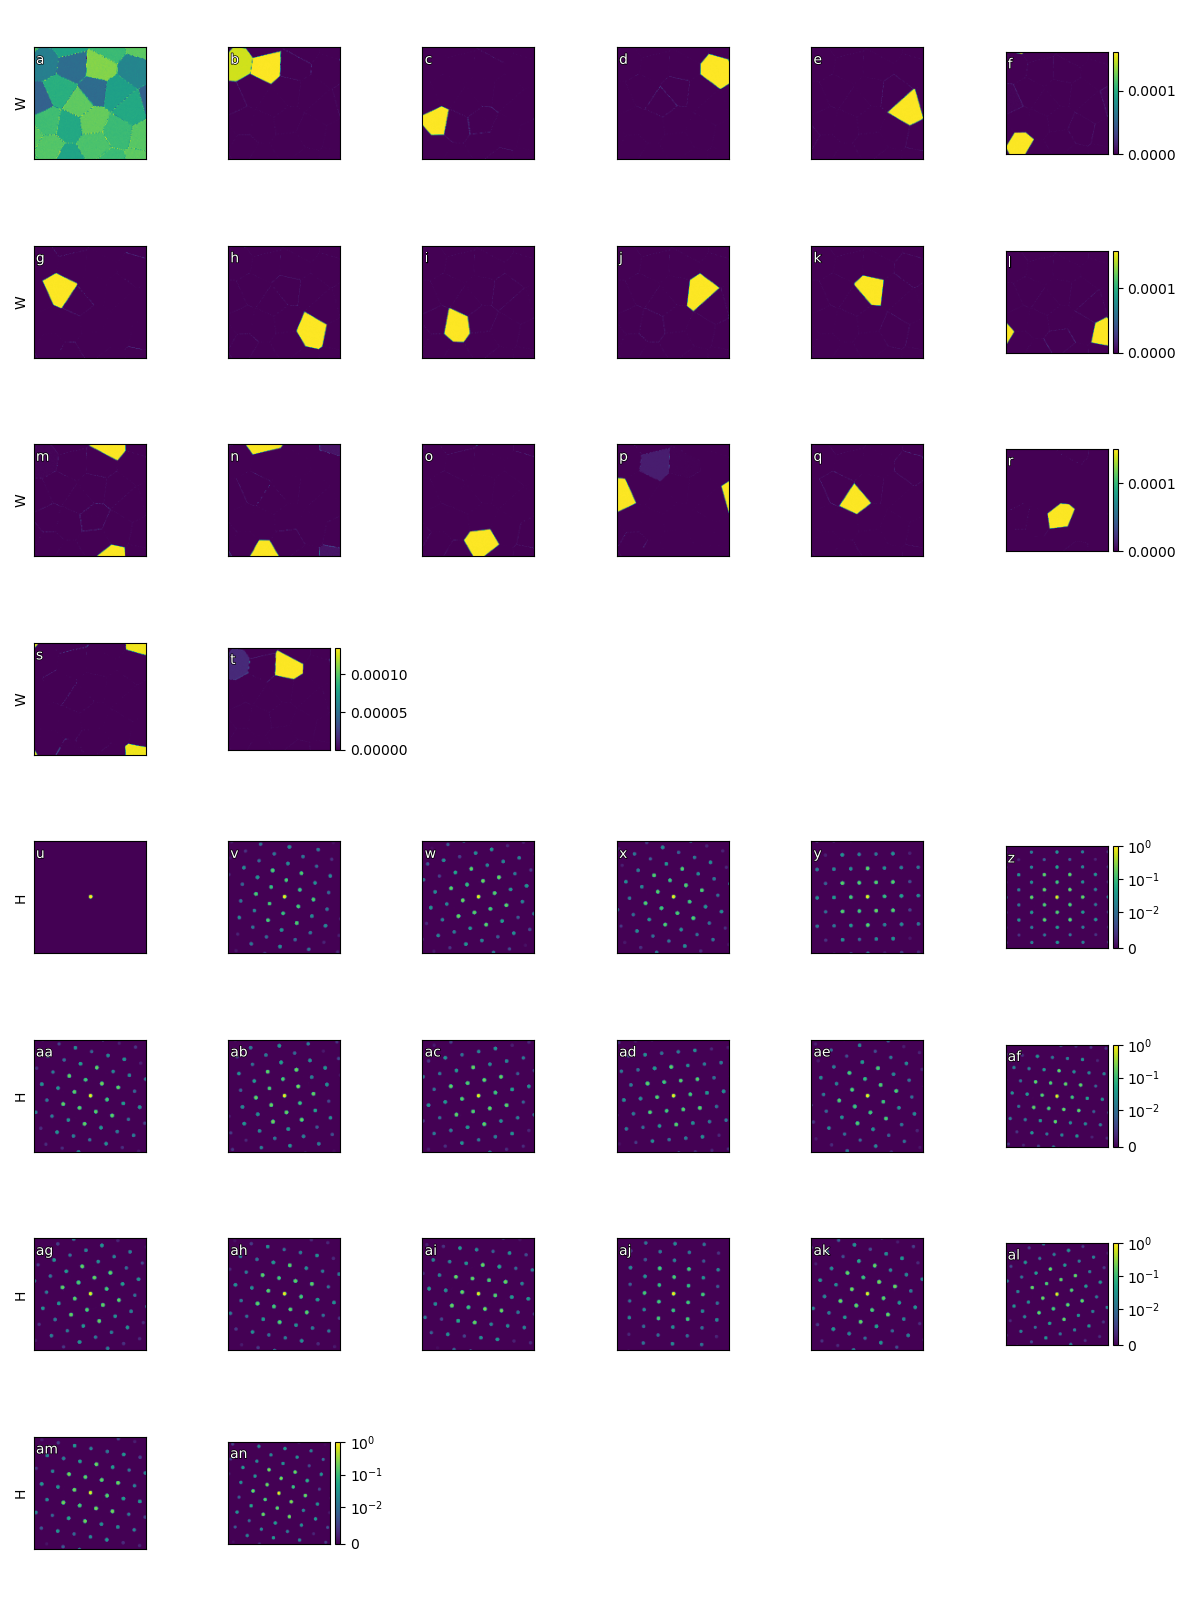

In [20]:
# Run NMF for k_PCA = 21
run_nmf_and_plot(k=20, ncols=6)
plt.savefig('figures/WS2_20.png', dpi=300)

In b) two clusters are merged. The ground truth shows that these have the same orientation and strain. They just have a different thickness, which is absorbed by the 'beam' component (a and u). These two grains were mapped separately by UMAP!

--- Running NMF and visualization for k = 21 ---


C:\Users\Andreas\AppData\Local\Temp\ipykernel_9936\2069280924.py:67: DeprecationWarning: Converting `np.complex` to a dtype is deprecated. The current result is `complex128` which is not strictly correct.
  if A.dtype == np.complexfloating:


Time taken to compute: 115.67 s


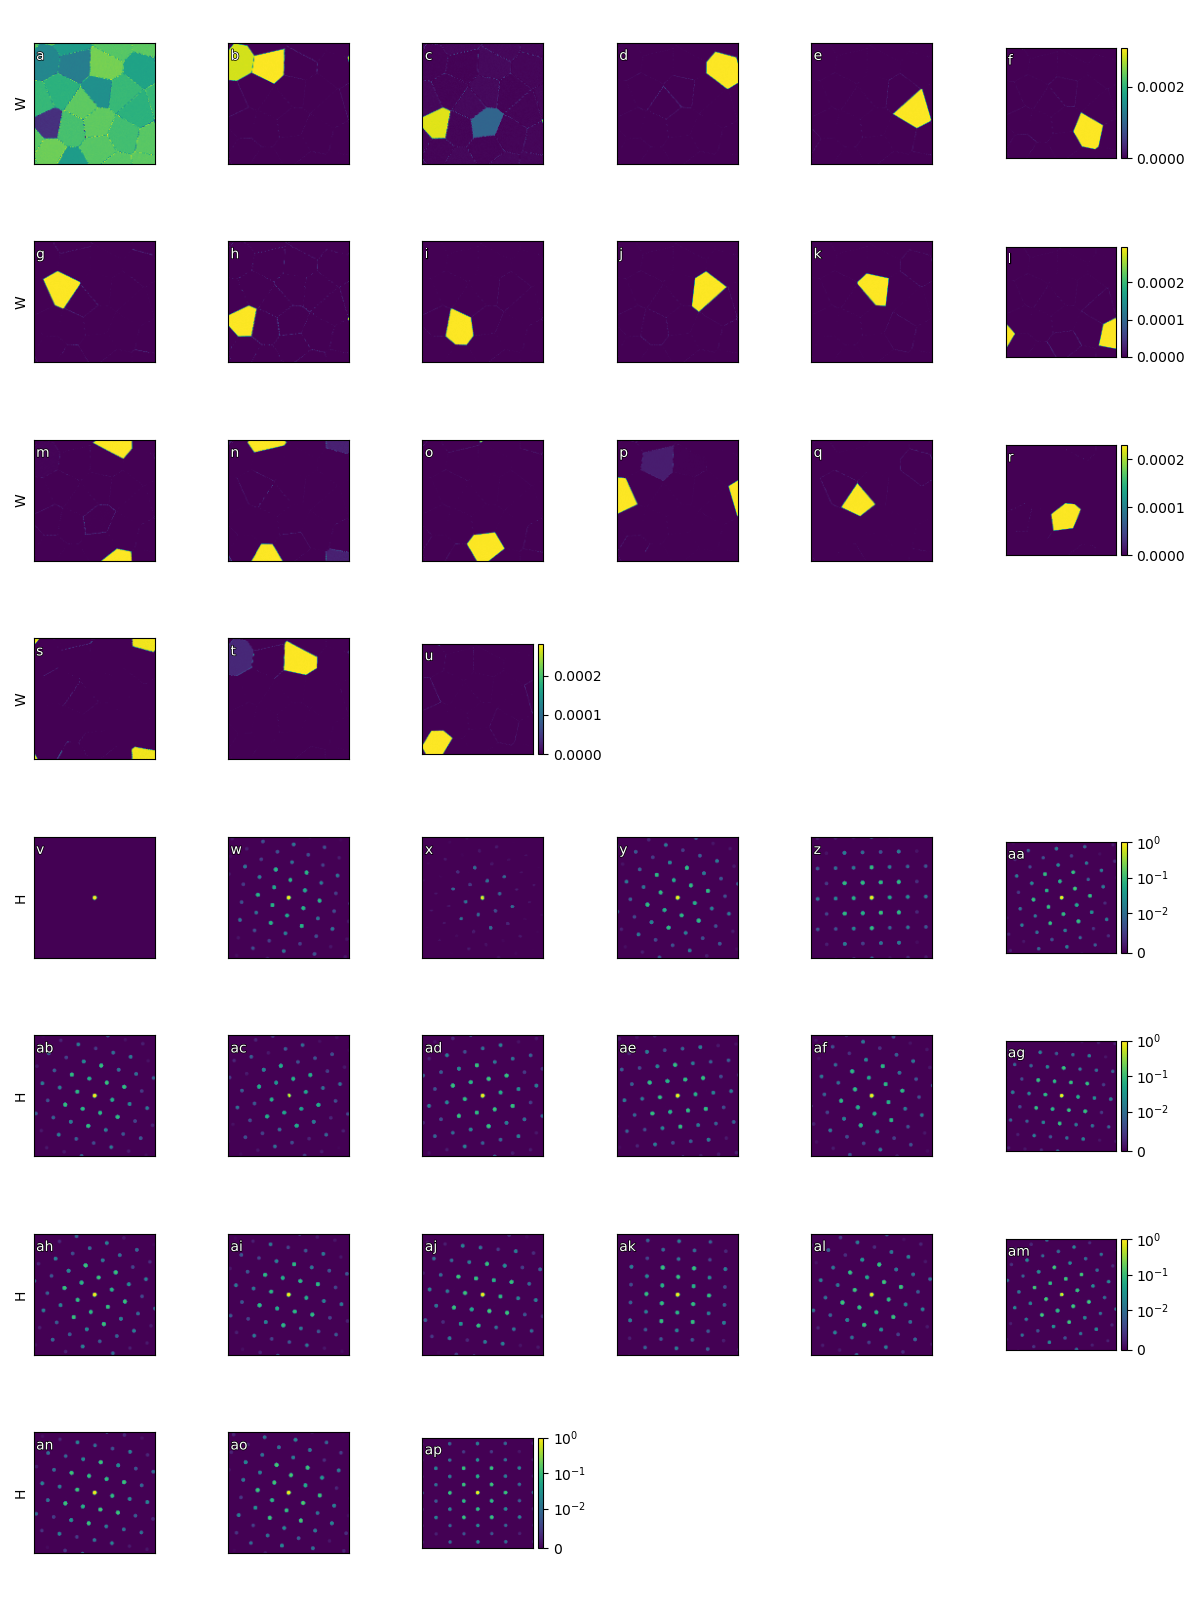

In [21]:
# Run NMF for k_PCA = 21
run_nmf_and_plot(k=21, ncols=6)

plt.savefig('figures/WS2_21.png', dpi=300)

With 21 components the most obvious difference is the addition of an additional beam component (h / ac). This component seems to accommodate some assymmetries happening at grain edges. 